In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

In [2]:
shots = 4096

three_qubit = QuantumCircuit(3,3)


for qubit in range(3):
    three_qubit.h(qubit)


three_qubit.measure([0,1,2],[0,1,2])


print(three_qubit.draw())

     ┌───┐┌─┐      
q_0: ┤ H ├┤M├──────
     ├───┤└╥┘┌─┐   
q_1: ┤ H ├─╫─┤M├───
     ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─╫──╫─┤M├
     └───┘ ║  ║ └╥┘
c: 3/══════╩══╩══╩═
           0  1  2 


In [3]:
backend = AerSimulator()

result = backend.run(
    three_qubit,
    shots=shots
).result()


distribution = result.get_counts()


print(distribution)

{'010': 493, '101': 527, '111': 551, '011': 482, '100': 506, '000': 505, '110': 508, '001': 524}


In [4]:
all_states=[]

for number in range(8):

    all_states.append(format(number,'03b'))


probabilities=[]


for item in all_states:

    probabilities.append(
        distribution.get(item,0)/shots
    )


print(probabilities)

[0.123291015625, 0.1279296875, 0.120361328125, 0.11767578125, 0.12353515625, 0.128662109375, 0.1240234375, 0.134521484375]


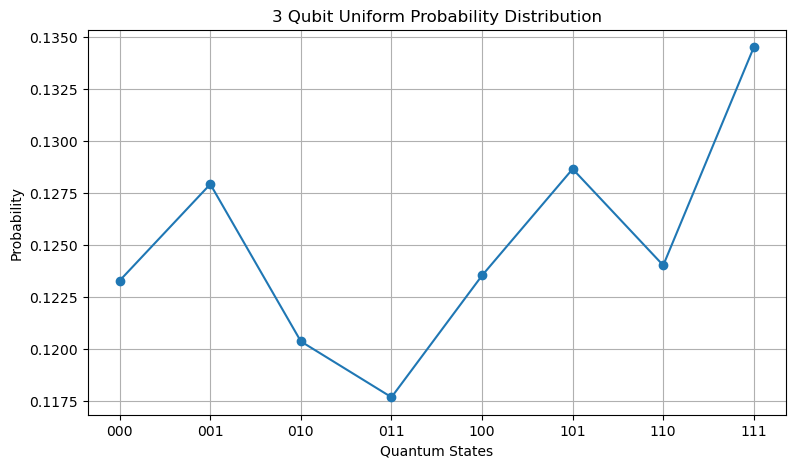

In [5]:
plt.figure(figsize=(9,5))


plt.plot(
    all_states,
    probabilities,
    marker='o'
)


plt.xlabel("Quantum States")

plt.ylabel("Probability")

plt.title("3 Qubit Uniform Probability Distribution")


plt.grid(True)

plt.show()

In [6]:
print("State     Measured     Expected")

print("------------------------------")


for state,prob in zip(all_states,probabilities):

    print(
        state,
        "   ",
        round(prob,4),
        "      ",
        0.125
    )

State     Measured     Expected
------------------------------
000     0.1233        0.125
001     0.1279        0.125
010     0.1204        0.125
011     0.1177        0.125
100     0.1235        0.125
101     0.1287        0.125
110     0.124        0.125
111     0.1345        0.125
